# Eksperimen Viralitas YouTube — v11 revisi
**XGBoost · Random Forest · Linear SVM | pemisahan berdasarkan kanal**

Seluruh kanal dipertahankan berdasarkan konfirmasi pemeriksaan peneliti. Notebook tidak menilai niche secara otomatis. Tujuannya **klasifikasi retrospektif** video ekstrem relatif terhadap video lain pada kanal yang sama dalam snapshot yang tersedia; bukan prediksi sejak unggah, klaim kausal, atau verifikasi usia penonton.

**Cara menjalankan di Colab**
1. Pilih runtime Python CPU, jalankan instalasi pada sesi baru; bila diminta, restart lalu lanjutkan dari impor.
2. Sesuaikan `DATA_PATH` dan `OUTPUT_ROOT` dengan lokasi di Drive. Folder lama `Metopen ` memiliki spasi terakhir.
3. Jalankan sel berurutan. Mode `full` untuk penelitian; `smoke` hanya uji fungsi dan tidak boleh dijadikan hasil skripsi.
4. Hasil, pembagian data, model, tabel, dan grafik tersimpan otomatis dalam folder run baru.

Preprocessing berada dalam CV; kalibrasi dan pemilihan ambang menggunakan kanal terpisah; SMOTENC menggantikan SMOTE biasa; AP ditulis dengan nama yang tepat; ketidakpastian diukur dengan bootstrap kanal.

**Test v10 sudah pernah dilihat.** Seed pembagian luar tetap 42 agar tidak mencari test yang lebih menguntungkan. Evaluasi ulang ini bukan konfirmasi independen pada data baru. Jangan mengganti konfigurasi setelah melihat test untuk mengejar skor.


## 1. Instalasi
Versi dipatok untuk reproduksibilitas, bukan klaim versi terbaru. Ditargetkan untuk Python 3.11–3.12. Jalankan pada sesi baru sebelum impor; restart bila Colab meminta. Konflik paket Colab lain yang tidak digunakan perlu dibedakan dari kegagalan impor eksperimen.


In [ ]:
%pip install -q scikit-learn==1.6.1 imbalanced-learn==0.13.0 xgboost==2.1.4 numpy==2.1.3 scipy==1.15.2 pandas==2.2.3 matplotlib==3.10.1 joblib==1.6.0


In [ ]:
import os,sys,json,hashlib,warnings,itertools,platform,time
from pathlib import Path
from datetime import datetime,timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn,imblearn,xgboost,scipy,joblib
from IPython.display import display
from sklearn.model_selection import StratifiedGroupKFold,RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,FunctionTransformer,OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV,calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (average_precision_score,roc_auc_score,precision_recall_curve,
    precision_score,recall_score,f1_score,accuracy_score,balanced_accuracy_score,
    confusion_matrix,brier_score_loss)
from sklearn.exceptions import ConvergenceWarning
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
warnings.filterwarnings('error',category=ConvergenceWarning)
VERSIONS={k:m.__version__ for k,m in [('numpy',np),('pandas',pd),('scikit-learn',sklearn),
    ('imbalanced-learn',imblearn),('xgboost',xgboost),('scipy',scipy),('joblib',joblib)]}
assert sklearn.__version__=='1.6.1','Restart runtime setelah instalasi.'
assert imblearn.__version__=='0.13.0' and xgboost.__version__=='2.1.4'
print(platform.python_version(),VERSIONS)


3.13.15 {'numpy': '2.1.3', 'pandas': '2.2.3', 'scikit-learn': '1.6.1', 'imbalanced-learn': '0.13.0', 'xgboost': '2.1.4', 'scipy': '1.15.2', 'joblib': '1.6.0'}


## 2. Konfigurasi sebelum melihat hasil
Empat bagian tidak berbagi kanal: **fit**, **calibration**, **threshold**, dan **test**. Sekitar 20% kanal menjadi test; 20% kanal development menjadi threshold, lalu 20% sisanya calibration. Jumlah video tidak harus mengikuti persentase tepat.

Sembilan eksperimen: tiga algoritma × tanpa/dengan SMOTENC memakai statistik kanal, ditambah tiga algoritma tanpa resampling dan tanpa statistik kanal. Ablasi dibandingkan dengan pasangan tanpa resampling. Semua menggunakan pembagian identik dan tuning tersendiri. SVM tetap linear seperti v10, bukan kernel RBF.

SMOTENC 0,25 berarti positif:negatif setelah resampling = 1:4, bukan prevalensi positif 25%. Ini pilihan desain tetap, bukan rasio optimal yang telah terbukti.


In [ ]:
MOUNT_DRIVE=True
DATA_PATH='/content/drive/MyDrive/Metopen /dataset_gabungan_final.csv'
OUTPUT_ROOT='/content/drive/MyDrive/Metopen /hasil_v11'
RUN_MODE='full'                 # 'full' penelitian; 'smoke' hanya uji fungsi
SEED=42
LABEL_THRESHOLD=2.0
START_DATE='2020-01-01T00:00:00Z'
END_DATE_EXCLUSIVE='2026-01-01T00:00:00Z'
REFERENCE_DATE=END_DATE_EXCLUSIVE # jangkar kalender, BUKAN tanggal scraping
SMOTE_RATIO=.25
SMOTE_K=3
RUN_ABLATION=True
RUN_IMPORTANCE=True
N_JOBS=2
assert RUN_MODE in {'full','smoke'}
CV_FOLDS=5 if RUN_MODE=='full' else 2
N_ITER_SEARCH=15 if RUN_MODE=='full' else 1
N_BOOTSTRAP=1000 if RUN_MODE=='full' else 20
N_PERMUTATIONS=10 if RUN_MODE=='full' else 2
if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
DATA_PATH=Path(DATA_PATH)
assert DATA_PATH.is_file(),f'CSV tidak ditemukan: {DATA_PATH}. Periksa spasi folder.'
RUN_ID=datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
OUT=Path(OUTPUT_ROOT)/f'{RUN_MODE}_{RUN_ID}'
OUT.mkdir(parents=True,exist_ok=False)
(OUT/'models').mkdir();(OUT/'figures').mkdir()
def save_json(name,obj):
    (OUT/name).write_text(json.dumps(obj,indent=2,ensure_ascii=False,default=str),encoding='utf-8')
print('Mode:',RUN_MODE,'| Hasil:',OUT)
if RUN_MODE=='smoke':print('UJI FUNGSI SAJA; skor bukan hasil skripsi.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mode: full | Hasil: /content/drive/MyDrive/Metopen /hasil_v11/full_20260924T041949924077Z


## 3. Pemeriksaan dataset
CSV asli tidak ditimpa. Duplikat identik dibuang, tetapi ID sama dengan isi berbeda menghentikan proses. Views nol dikeluarkan agar konsisten dengan eksperimen asal, **bukan karena nol selalu data rusak**. Statistik yang sudah diganti nol oleh scraper saat tidak tersedia tidak dapat dipulihkan; tulis sebagai keterbatasan.

Outcome hilang/negatif tidak diimputasi untuk membuat label. Semua kanal yang memiliki video layak tetap dipertahankan, tanpa seleksi berdasarkan skor model.


In [ ]:
with DATA_PATH.open('rb') as f:DATA_SHA256=hashlib.file_digest(f,'sha256').hexdigest()
raw=pd.read_csv(DATA_PATH,dtype={'video_id':str,'channel_id':str})
required=['video_id','channel_id','channel_title','title','description','tags','published_at',
    'duration_seconds','view_count','like_count','comment_count',
    'channel_subscriber_count','channel_total_views','channel_video_count']
assert set(required)<=set(raw.columns),f'Kolom hilang: {set(required)-set(raw.columns)}'
raw['source_row']=np.arange(len(raw))
assert raw[['video_id','channel_id']].notna().all().all()
for c in ['video_id','channel_id']:
    raw[c]=raw[c].str.strip();assert raw[c].ne('').all()
df=raw.drop_duplicates(subset=required).copy()
assert not df.video_id.duplicated().any(),'Konflik metadata pada ID video sama; periksa dahulu.'
outcomes=['view_count','like_count','comment_count']
channel_stats=['channel_subscriber_count','channel_total_views','channel_video_count']
for c in ['duration_seconds']+outcomes+channel_stats:df[c]=pd.to_numeric(df[c],errors='coerce')
assert np.isfinite(df[outcomes].to_numpy()).all() and df[outcomes].ge(0).all().all(),'Outcome tidak valid.'
for c in channel_stats:df[c]=df[c].where(np.isfinite(df[c]) & df[c].ge(0))
df['published_at']=pd.to_datetime(df.published_at,errors='coerce',utc=True)
flags=pd.DataFrame(index=df.index)
flags['invalid_date']=df.published_at.isna()
flags['invalid_duration']=~np.isfinite(df.duration_seconds)|df.duration_seconds.le(0)
flags['zero_views']=df.view_count.eq(0)
flags['outside_period']=(~flags.invalid_date)&(df.published_at.lt(pd.Timestamp(START_DATE))|df.published_at.ge(pd.Timestamp(END_DATE_EXCLUSIVE)))
excluded=df.loc[flags.any(axis=1),['source_row','video_id','channel_id']].join(flags)
excluded.to_csv(OUT/'excluded_rows.csv',index=False)
df=df.loc[~flags.any(axis=1)].reset_index(drop=True)
assert len(df)>0
cleaning={'raw_rows':len(raw),'exact_duplicates':len(raw)-len(flags),
    'exclusion_flags_nonexclusive':flags.sum().to_dict(),'excluded_unique':len(excluded),
    'clean_rows':len(df),'channels':df.channel_id.nunique(),'sha256':DATA_SHA256}
save_json('data_audit.json',cleaning);print(cleaning)


{'raw_rows': 38963, 'exact_duplicates': 0, 'exclusion_flags_nonexclusive': {'invalid_date': 0, 'invalid_duration': 34, 'zero_views': 32, 'outside_period': 0}, 'excluded_unique': 34, 'clean_rows': 38929, 'channels': 218, 'sha256': 'a8ce478d27b368fc67629e2552325aabbdf62f9187c003bde139de1030e193c2'}


## 4. Label dan fitur
Label tetap AND: z-score `log1p(views)` > 2 dan z-score `log1p(likes+comments)` > 2 per kanal (`ddof=0`). Kanal utuh berada di satu bagian; statistik label tidak menggabungkan kanal fit dan test. Namun label memerlukan outcome seluruh sampel kanal: ini definisi **retrospektif**, bukan label yang tersedia saat unggah.

Ambang 1,5 dan 2,5 hanya sensitivitas **jumlah label**, bukan uji model ataupun cara memilih ambang setelah melihat test. Kanal ≤5 video tidak mungkin memiliki z > 2; tetap dicatat dan dipertahankan.

`video_age_days` adalah jarak ke 1 Januari 2026 UTC, bukan umur saat scraping. Statistik kanal adalah snapshot dan dapat mencerminkan popularitas yang sudah terjadi; ablasi tanpa statistik kanal wajib dibandingkan. Bahkan ablasi tidak membuktikan prediksi sejak unggah karena judul/deskripsi juga snapshot. Views, likes, comments, ID, dan komponen pembentuk label tidak menjadi fitur.


In [ ]:
def safe_zscore(s):
    sd=s.std(ddof=0)
    return (s-s.mean())/sd if pd.notna(sd) and sd>0 else pd.Series(0.,index=s.index)
df['log_views']=np.log1p(df.view_count)
df['log_interactions']=np.log1p(df.like_count+df.comment_count)
df['z_spread']=df.groupby('channel_id').log_views.transform(safe_zscore)
df['z_interact']=df.groupby('channel_id').log_interactions.transform(safe_zscore)
df['is_viral']=((df.z_spread>LABEL_THRESHOLD)&(df.z_interact>LABEL_THRESHOLD)).astype(int)
for c in ['description','tags']:
    df[c]=df[c].fillna('').astype(str)
    df['has_'+c]=df[c].str.strip().ne('').astype(int)
df['title_length']=df.title.fillna('').astype(str).str.len()
df['description_length']=df.description.str.len()
df['tag_count']=df.tags.map(lambda s:sum(bool(t.strip()) for t in s.split('|')))
df['video_age_days']=(pd.Timestamp(REFERENCE_DATE)-df.published_at).dt.days.clip(lower=1)
df['publish_month']=df.published_at.dt.month
df['publish_dayofweek']=df.published_at.dt.dayofweek
NUM_BASE=['duration_seconds','video_age_days','title_length','description_length','tag_count']
CAT=['has_description','has_tags','publish_month','publish_dayofweek']
FEATURE_SETS={'snapshot':NUM_BASE+channel_stats+CAT,'no_channel_stats':NUM_BASE+CAT}
FORBIDDEN=set(outcomes+['is_viral','log_views','log_interactions','z_spread','z_interact','channel_id','video_id'])
assert not any(FORBIDDEN.intersection(v) for v in FEATURE_SETS.values())
channel_summary=df.groupby('channel_id').agg(channel_title=('channel_title','first'),n=('video_id','size'),positives=('is_viral','sum'))
channel_summary['z2_impossible_n_le_5']=channel_summary.n.le(5)
channel_summary.to_csv(OUT/'channel_label_summary.csv')
sensitivity=pd.DataFrame([{'label_threshold':t,'positive_count':int(((df.z_spread>t)&(df.z_interact>t)).sum())} for t in [1.5,2,2.5]])
sensitivity.to_csv(OUT/'label_count_sensitivity.csv',index=False)
df.to_csv(OUT/'dataset_clean_labeled.csv',index=False)
print('Video:',len(df),'| Kanal:',df.channel_id.nunique(),'| Viral:',int(df.is_viral.sum()))
display(sensitivity);display(channel_summary[channel_summary.z2_impossible_n_le_5])
KNOWN_SHA='a8ce478d27b368fc67629e2552325aabbdf62f9187c003bde139de1030e193c2'
if DATA_SHA256==KNOWN_SHA:
    assert (len(df),df.channel_id.nunique(),int(df.is_viral.sum()))==(38929,218,712)
    print('Jumlah dataset asli cocok: 38.929 / 218 / 712.')


Video: 38929 | Kanal: 218 | Viral: 712


,label_threshold,positive_count
0,1.5,1817
1,2.0,712
2,2.5,293


,channel_title,n,positives,z2_impossible_n_le_5
channel_id,,,,
UCYPSqQRAl-E7SyIAPz-9GDA,Arsyla Mahestri Rahayu,3,0,True


Jumlah dataset asli cocok: 38.929 / 218 / 712.


## 5. Pembagian kanal dan manifest
Fold pertama dipakai secara tetap, tanpa mencari seed yang menghasilkan skor lebih baik. Stratifikasi tidak menjamin proporsi persis sama. Semua bagian dan fold harus memiliki dua kelas; jika tidak, notebook berhenti.

CV hanya pada bagian fit. Calibration, threshold, dan test tidak di-resample. Setelah kalibrasi/ambang dipilih, model **tidak dilatih ulang pada gabungan bagian**, karena hal itu akan mengubah model yang dievaluasi. Pengurangan data untuk model dasar merupakan kompromi agar pemisahan mudah diaudit.


In [ ]:
def first_group_split(indices,n_splits,seed):
    indices=np.asarray(indices);sub=df.iloc[indices]
    splitter=StratifiedGroupKFold(n_splits=n_splits,shuffle=True,random_state=seed)
    tr,va=next(splitter.split(np.zeros((len(sub),1)),sub.is_viral,sub.channel_id))
    return indices[tr],indices[va]
dev_idx,test_idx=first_group_split(np.arange(len(df)),5,SEED)
fitcal_idx,threshold_idx=first_group_split(dev_idx,5,SEED+1)
fit_idx,calibration_idx=first_group_split(fitcal_idx,5,SEED+2)
PARTS={'fit':fit_idx,'calibration':calibration_idx,'threshold':threshold_idx,'test':test_idx}
assert len(np.unique(np.concatenate(list(PARTS.values()))))==len(df)
for (an,ai),(bn,bi) in itertools.combinations(PARTS.items(),2):
    assert set(df.iloc[ai].channel_id).isdisjoint(df.iloc[bi].channel_id),f'Overlap {an}/{bn}'
for name,idx in PARTS.items():assert df.iloc[idx].is_viral.nunique()==2,f'{name} tidak memiliki dua kelas.'
manifest=df[['source_row','video_id','channel_id','is_viral']].copy();manifest['partition']=''
for name,idx in PARTS.items():manifest.loc[idx,'partition']=name
manifest.to_csv(OUT/'split_manifest.csv',index=False)
split_summary=manifest.groupby('partition',sort=False).agg(videos=('video_id','size'),channels=('channel_id','nunique'),positives=('is_viral','sum'))
split_summary['positive_rate']=split_summary.positives/split_summary.videos
split_summary.to_csv(OUT/'split_summary.csv');display(split_summary)
fit_data=df.iloc[fit_idx].reset_index(drop=True)
y_fit=fit_data.is_viral.to_numpy();g_fit=fit_data.channel_id.to_numpy()
cv=StratifiedGroupKFold(n_splits=CV_FOLDS,shuffle=True,random_state=SEED+3)
CV_SPLITS=list(cv.split(np.zeros((len(fit_data),1)),y_fit,g_fit))
cv_rows=[];cv_manifest=[]
for fold,(tr,va) in enumerate(CV_SPLITS):
    assert set(g_fit[tr]).isdisjoint(g_fit[va])
    assert len(np.unique(y_fit[tr]))==2 and len(np.unique(y_fit[va]))==2
    assert y_fit[tr].sum()>SMOTE_K
    assert y_fit[tr].sum()/(len(tr)-y_fit[tr].sum())<SMOTE_RATIO
    cv_rows.append({'fold':fold,'train_n':len(tr),'valid_n':len(va),'train_positive':int(y_fit[tr].sum()),'valid_positive':int(y_fit[va].sum())})
    cv_manifest.extend({'video_id':fit_data.iloc[j].video_id,'channel_id':g_fit[j],'validation_fold':fold} for j in va)
pd.DataFrame(cv_rows).to_csv(OUT/'cv_summary.csv',index=False)
pd.DataFrame(cv_manifest).to_csv(OUT/'cv_manifest.csv',index=False)
# EDA deskriptif pada fit; tidak ada p-value per video yang mengabaikan dependensi kanal.
fit_data.groupby('is_viral')[FEATURE_SETS['snapshot']].median().to_csv(OUT/'fit_class_medians.csv')
fit_data[FEATURE_SETS['snapshot']].corr(method='spearman').to_csv(OUT/'fit_feature_spearman.csv')
display(pd.DataFrame(cv_rows))


,videos,channels,positives,positive_rate
partition,,,,
fit,19573,111,349,0.017831
test,7639,44,149,0.019505
threshold,6749,35,107,0.015854
calibration,4968,28,107,0.021538


,fold,train_n,valid_n,train_positive,valid_positive
0,0,15805,3768,282,67
1,1,15372,4201,262,87
2,2,16005,3568,288,61
3,3,15473,4100,275,74
4,4,15637,3936,289,60


## 6. Pipeline dan ruang pencarian
Numerik: imputasi median → log1p → standardisasi. Kategorikal: imputasi → SMOTENC jika digunakan → one-hot. Seluruh langkah yang dipelajari berada di dalam pipeline CV. Log1p mengurangi rentang yang sangat timpang untuk perhitungan jarak.

SMOTENC menjaga nilai kategori, tetapi **tidak menjamin semua kombinasi fitur sintetis realistis** (misalnya flag kosong versus panjang teks). Tetangga dapat berasal dari kanal berbeda dalam pelatihan. Ini analisis sensitivitas, bukan pembuatan video nyata; baseline tanpa resampling tetap dilaporkan.

AP CV adalah rata-rata per fold dan merupakan skor seleksi, bukan estimasi bebas bias pemilihan. AP test dihitung pada kumpulan video test; kedua agregasi tidak identik.


In [ ]:
CATEGORY_VALUES=[[0,1],[0,1],list(range(1,13)),list(range(7))]
def make_pipeline(algorithm,feature_set,use_smote):
    num=[c for c in FEATURE_SETS[feature_set] if c not in CAT]
    pre=ColumnTransformer([
        ('numeric',Pipeline([('imputer',SimpleImputer(strategy='median',keep_empty_features=True)),
            ('log',FunctionTransformer(np.log1p,feature_names_out='one-to-one')),
            ('scale',StandardScaler())]),num),
        ('categorical',SimpleImputer(strategy='most_frequent',keep_empty_features=True),CAT)],sparse_threshold=0)
    positions=list(range(len(num),len(num)+len(CAT)))
    sampler=SMOTENC(categorical_features=positions,sampling_strategy=SMOTE_RATIO,
        k_neighbors=SMOTE_K,random_state=SEED) if use_smote else 'passthrough'
    encode=ColumnTransformer([('numeric','passthrough',list(range(len(num)))),
        ('categorical',OneHotEncoder(categories=CATEGORY_VALUES,handle_unknown='error',sparse_output=False),positions)],sparse_threshold=0)
    if algorithm=='XGBoost':
        model=XGBClassifier(objective='binary:logistic',eval_metric='logloss',tree_method='hist',random_state=SEED,n_jobs=1)
        params={'clf__n_estimators':[100,200,300],'clf__max_depth':[3,4,5,6],
            'clf__learning_rate':[.01,.05,.1,.2],'clf__subsample':[.7,.85,1.],'clf__colsample_bytree':[.7,.85,1.]}
    elif algorithm=='RandomForest':
        model=RandomForestClassifier(random_state=SEED,n_jobs=1)
        params={'clf__n_estimators':[100,200,300],'clf__max_depth':[5,10,15,None],
            'clf__min_samples_split':[2,5,10],'clf__min_samples_leaf':[1,2,4],'clf__max_features':['sqrt','log2']}
    elif algorithm=='LinearSVM':
        model=LinearSVC(dual='auto',random_state=SEED,max_iter=50000)
        params={'clf__C':[.001,.01,.1,1.,10.,100.,1000.]}
    else:raise ValueError(algorithm)
    if RUN_MODE=='smoke':
        params={'clf__C':[.01]} if algorithm=='LinearSVM' else {'clf__n_estimators':[20],'clf__max_depth':[3]}
    return ImbPipeline([('pre',pre),('sample',sampler),('encode',encode),('clf',model)]),params
EXPERIMENTS=[{'name':f'{alg}__snapshot__{bal}','algorithm':alg,'feature_set':'snapshot',
    'smotenc':bal=='SMOTENC','role':'primary'} for alg in ['XGBoost','RandomForest','LinearSVM'] for bal in ['original','SMOTENC']]
if RUN_ABLATION:
    EXPERIMENTS += [{'name':f'{alg}__no_channel_stats__original','algorithm':alg,
        'feature_set':'no_channel_stats','smotenc':False,'role':'ablation'} for alg in ['XGBoost','RandomForest','LinearSVM']]
config=dict(run_mode=RUN_MODE,seed=SEED,label_threshold=LABEL_THRESHOLD,start_date=START_DATE,
    end_date_exclusive=END_DATE_EXCLUSIVE,reference_date=REFERENCE_DATE,smote_ratio=SMOTE_RATIO,
    smote_k=SMOTE_K,cv_folds=CV_FOLDS,n_iter=N_ITER_SEARCH,n_bootstrap=N_BOOTSTRAP,
    n_permutations=N_PERMUTATIONS,versions=VERSIONS,data_sha256=DATA_SHA256,
    feature_sets=FEATURE_SETS,experiments=EXPERIMENTS)
save_json('configuration.json',config);display(pd.DataFrame(EXPERIMENTS))


,name,algorithm,feature_set,smotenc,role
0,XGBoost__snapshot__original,XGBoost,snapshot,False,primary
1,XGBoost__snapshot__SMOTENC,XGBoost,snapshot,True,primary
2,RandomForest__snapshot__original,RandomForest,snapshot,False,primary
3,RandomForest__snapshot__SMOTENC,RandomForest,snapshot,True,primary
4,LinearSVM__snapshot__original,LinearSVM,snapshot,False,primary
5,LinearSVM__snapshot__SMOTENC,LinearSVM,snapshot,True,primary
6,XGBoost__no_channel_stats__original,XGBoost,no_channel_stats,False,ablation
7,RandomForest__no_channel_stats__original,RandomForest,no_channel_stats,False,ablation
8,LinearSVM__no_channel_stats__original,LinearSVM,no_channel_stats,False,ablation


## 7. Tuning, kalibrasi, dan ambang tanpa test
Parameter dipilih lewat CV pada fit. Model terbaik di-refit pada seluruh fit kemudian dibekukan; sigmoid dilatih pada calibration dengan distribusi asli. Ketiga algoritma menjalani proses sama. Tidak ada kalibrasi internal SVM dengan pembagian video acak.

Ambang F1 terbaik dipilih pada threshold; bila seri dipilih ambang tertinggi. F1 bagian ini adalah skor optimasi, bukan generalisasi. Model utama dipilih melalui AP CV sebelum evaluasi test. Nilai 0,5 hanya pembanding. Kalibrasi tidak dijamin sempurna; Brier score dan kurva dilaporkan.


In [ ]:
def choose_threshold(y,p):
    precision,recall,thresholds=precision_recall_curve(y,p)
    denom=precision[:-1]+recall[:-1]
    f1=np.divide(2*precision[:-1]*recall[:-1],denom,out=np.zeros(len(thresholds)),where=denom>0)
    best=np.flatnonzero(np.isclose(f1,f1.max(),rtol=0,atol=1e-12))[-1]
    return float(thresholds[best]),float(f1[best])
models={};decisions=[]
for spec in EXPERIMENTS:
    name=spec['name'];cols=FEATURE_SETS[spec['feature_set']]
    print('Memproses:',name,flush=True);started=time.time()
    pipe,params=make_pipeline(spec['algorithm'],spec['feature_set'],spec['smotenc'])
    combinations=int(np.prod([len(v) for v in params.values()]))
    search=RandomizedSearchCV(pipe,params,n_iter=min(N_ITER_SEARCH,combinations),
        scoring='average_precision',cv=CV_SPLITS,refit=True,random_state=SEED,
        n_jobs=N_JOBS,pre_dispatch=N_JOBS,error_score='raise',return_train_score=False)
    # Thread menjaga filter warning konvergensi aktif pada setiap kandidat.
    with joblib.parallel_backend('threading'):
        search.fit(fit_data[cols],y_fit)
    base=search.best_estimator_
    calibrated=CalibratedClassifierCV(FrozenEstimator(base),method='sigmoid',ensemble=False)
    calibrated.fit(df.iloc[calibration_idx][cols],df.iloc[calibration_idx].is_viral)
    p_threshold=calibrated.predict_proba(df.iloc[threshold_idx][cols])[:,1]
    assert np.isfinite(p_threshold).all()
    threshold,f1_selection=choose_threshold(df.iloc[threshold_idx].is_viral,p_threshold)
    models[name]=calibrated
    row={**spec,'best_cv_ap':float(search.best_score_),'best_params':search.best_params_,
        'threshold':threshold,'threshold_selection_f1':f1_selection,'elapsed_seconds':time.time()-started}
    decisions.append(row)
    pd.DataFrame(search.cv_results_).to_csv(OUT/f'cv_search_{name}.csv',index=False)
    pd.DataFrame({'video_id':df.iloc[threshold_idx].video_id.to_numpy(),
        'y':df.iloc[threshold_idx].is_viral.to_numpy(),'p':p_threshold}).to_csv(OUT/f'threshold_predictions_{name}.csv',index=False)
    joblib.dump({'model':calibrated,'features':cols,'threshold':threshold,'config':config},OUT/'models'/f'{name}.joblib')
    save_json('model_decisions.json',decisions)
    print(f'  AP CV={search.best_score_:.4f}; ambang={threshold:.6f}; detik={time.time()-started:.1f}',flush=True)
selection=pd.DataFrame(decisions);primary=selection[selection.role.eq('primary')]
selected_name=primary.sort_values(['best_cv_ap','name'],ascending=[False,True]).iloc[0]['name']
save_json('selection_locked_before_test.json',{'selected_model':selected_name,
    'criterion':'mean fit-only group-CV AP; alphabetical tie-break','decisions':decisions})
LOCKED_DECISIONS_SHA=hashlib.sha256((OUT/'model_decisions.json').read_bytes()).hexdigest()
print('Model pilihan sebelum test:',selected_name)
display(selection[['name','best_cv_ap','threshold','threshold_selection_f1']])


Memproses: XGBoost__snapshot__original
  AP CV=0.0401; ambang=0.017715; detik=69.0
Memproses: XGBoost__snapshot__SMOTENC
  AP CV=0.0356; ambang=0.018095; detik=136.6
Memproses: RandomForest__snapshot__original
  AP CV=0.0478; ambang=0.022795; detik=187.6
Memproses: RandomForest__snapshot__SMOTENC
  AP CV=0.0335; ambang=0.018553; detik=360.7
Memproses: LinearSVM__snapshot__original
  AP CV=0.0211; ambang=0.027800; detik=3.6
Memproses: LinearSVM__snapshot__SMOTENC
  AP CV=0.0207; ambang=0.027606; detik=48.8
Memproses: XGBoost__no_channel_stats__original
  AP CV=0.0300; ambang=0.019650; detik=32.3
Memproses: RandomForest__no_channel_stats__original
  AP CV=0.0257; ambang=0.025195; detik=177.3
Memproses: LinearSVM__no_channel_stats__original
  AP CV=0.0185; ambang=0.019094; detik=3.2
Model pilihan sebelum test: RandomForest__snapshot__original


,name,best_cv_ap,threshold,threshold_selection_f1
0,XGBoost__snapshot__original,0.040063,0.017715,0.031693
1,XGBoost__snapshot__SMOTENC,0.035638,0.018095,0.033308
2,RandomForest__snapshot__original,0.047754,0.022795,0.034640
3,RandomForest__snapshot__SMOTENC,0.033489,0.018553,0.034257
4,LinearSVM__snapshot__original,0.021139,0.027800,0.046809
5,LinearSVM__snapshot__SMOTENC,0.020722,0.027606,0.041152
6,XGBoost__no_channel_stats__original,0.030002,0.019650,0.037028
7,RandomForest__no_channel_stats__original,0.025722,0.025195,0.042875
8,LinearSVM__no_channel_stats__original,0.018519,0.019094,0.032005


## 8. Evaluasi akhir dan baseline
Seluruh eksperimen yang direncanakan dilaporkan. Peringkat test boleh dideskripsikan, tetapi tidak dipakai mengubah model atau melakukan tuning baru. `average_precision_score` disebut **Average Precision (AP)**, bukan luas trapezoid PR.

Skor konstan mempunyai AP sama dengan prevalensi positif test. Akurasi dilaporkan bersama precision, recall, F1 positif, AP, ROC-AUC, balanced accuracy, Brier score, dan confusion matrix. Nilai akurasi tinggi sendiri tidak cukup.


In [ ]:
assert hashlib.sha256((OUT/'model_decisions.json').read_bytes()).hexdigest()==LOCKED_DECISIONS_SHA
Y_TEST=df.iloc[test_idx].is_viral.to_numpy();G_TEST=df.iloc[test_idx].channel_id.to_numpy()
TEST_P={};TEST_PRED={};result_rows=[]
def metric_row(y,p,pred):
    tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    return {'average_precision':average_precision_score(y,p),'roc_auc':roc_auc_score(y,p),
        'precision':precision_score(y,pred,zero_division=0),'recall':recall_score(y,pred,zero_division=0),
        'f1':f1_score(y,pred,zero_division=0),'accuracy':accuracy_score(y,pred),
        'balanced_accuracy':balanced_accuracy_score(y,pred),'brier':brier_score_loss(y,p),
        'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp),'predicted_positive':int(pred.sum())}
for row in decisions:
    name=row['name'];cols=FEATURE_SETS[row['feature_set']]
    p=models[name].predict_proba(df.iloc[test_idx][cols])[:,1]
    assert np.isfinite(p).all() and ((0<=p)&(p<=1)).all()
    pred=(p>=row['threshold']).astype(int)
    TEST_P[name]=p;TEST_PRED[name]=pred
    result_rows.append({'name':name,'role':row['role'],'selected_before_test':name==selected_name,
        'threshold':row['threshold'],**metric_row(Y_TEST,p,pred),
        'f1_default_05':f1_score(Y_TEST,p>=.5,zero_division=0),'run_mode':RUN_MODE})
    pd.DataFrame({'video_id':df.iloc[test_idx].video_id.to_numpy(),'channel_id':G_TEST,
        'y':Y_TEST,'probability':p,'prediction':pred}).to_csv(OUT/f'test_predictions_{name}.csv',index=False)
results=pd.DataFrame(result_rows);results.to_csv(OUT/'test_results.csv',index=False)
constant=np.full(len(Y_TEST),float(y_fit.mean()))
baselines=pd.DataFrame([{'name':'all_negative',**metric_row(Y_TEST,constant,np.zeros(len(Y_TEST),dtype=int))},
    {'name':'all_positive',**metric_row(Y_TEST,constant,np.ones(len(Y_TEST),dtype=int))}])
baselines.to_csv(OUT/'baseline_results.csv',index=False)
print('Prevalensi test / AP skor konstan:',Y_TEST.mean())
display(results[['name','average_precision','precision','recall','f1','roc_auc','brier']]);display(baselines)


Prevalensi test / AP skor konstan: 0.01950517083387878


,name,average_precision,precision,recall,f1,roc_auc,brier
0,XGBoost__snapshot__original,0.030412,0.019884,0.993289,0.038988,0.596306,0.019425
1,XGBoost__snapshot__SMOTENC,0.027258,0.021507,0.825503,0.041922,0.575511,0.019097
2,RandomForest__snapshot__original,0.028487,0.025331,0.295302,0.046660,0.551798,0.019102
3,RandomForest__snapshot__SMOTENC,0.023853,0.021587,0.724832,0.041925,0.562744,0.019116
4,LinearSVM__snapshot__original,0.022800,0.028501,0.154362,0.048117,0.556518,0.019125
5,LinearSVM__snapshot__SMOTENC,0.023175,0.025473,0.234899,0.045962,0.563273,0.019136
6,XGBoost__no_channel_stats__original,0.025592,0.021379,0.684564,0.041463,0.556365,0.019139
7,RandomForest__no_channel_stats__original,0.023039,0.024621,0.087248,0.038405,0.549464,0.019131
8,LinearSVM__no_channel_stats__original,0.025054,0.019613,0.979866,0.038456,0.564452,0.019119


,name,average_precision,roc_auc,precision,recall,f1,accuracy,balanced_accuracy,brier,tn,fp,fn,tp,predicted_positive
0,all_negative,0.019505,0.5,0.000000,0.0,0.000000,0.980495,0.5,0.019128,7490,0,149,0,0
1,all_positive,0.019505,0.5,0.019505,1.0,0.038264,0.019505,0.5,0.019128,0,7490,0,149,7639


## 9. Bootstrap kanal dan perbandingan berpasangan
Kanal test diambil ulang dengan pengembalian; semua videonya ikut diambil, termasuk pengulangan jika kanal terambil dua kali. Replikasi satu kelas dilewati dan jumlahnya dicatat. Interval persentil 95% bersyarat pada model/split saat ini, tidak mencakup variasi pelatihan ulang atau bias seleksi kanal.

Perbandingan menggunakan replikasi kanal yang sama: SMOTENC minus original, dan tanpa statistik kanal minus snapshot pada model tanpa resampling. Interval bersifat eksploratif, bukan klaim keunggulan universal atau uji signifikansi massal.


In [ ]:
rng=np.random.default_rng(SEED+10)
unique_groups=np.unique(G_TEST)
group_rows=[np.flatnonzero(G_TEST==g) for g in unique_groups]
boot={name:[] for name in TEST_P};skipped=0
for b in range(N_BOOTSTRAP):
    idx=np.concatenate([group_rows[j] for j in rng.integers(0,len(group_rows),len(group_rows))])
    yy=Y_TEST[idx]
    if len(np.unique(yy))<2:skipped+=1;continue
    for name,p in TEST_P.items():
        boot[name].append([average_precision_score(yy,p[idx]),f1_score(yy,TEST_PRED[name][idx],zero_division=0)])
assert N_BOOTSTRAP-skipped>=max(10,int(.8*N_BOOTSTRAP)),'Terlalu sedikit replikasi valid.'
ci_rows=[]
for name,v in boot.items():
    arr=np.asarray(v)
    for j,metric in enumerate(['average_precision','f1']):
        lo,hi=np.quantile(arr[:,j],[.025,.975])
        ci_rows.append({'name':name,'metric':metric,'estimate':float(results.set_index('name').loc[name,metric]),
            'lower_95':lo,'upper_95':hi,'valid_replicates':len(v),'skipped':skipped})
ci=pd.DataFrame(ci_rows);ci.to_csv(OUT/'cluster_bootstrap_ci.csv',index=False)
pairs=[]
for alg in ['XGBoost','RandomForest','LinearSVM']:
    pairs.append((f'{alg}__snapshot__SMOTENC',f'{alg}__snapshot__original','SMOTENC minus original'))
    if RUN_ABLATION:pairs.append((f'{alg}__no_channel_stats__original',f'{alg}__snapshot__original','no_channel minus snapshot'))
paired=[]
for left,right,comparison in pairs:
    delta=np.asarray(boot[left])-np.asarray(boot[right])
    for j,metric in enumerate(['average_precision','f1']):
        lo,hi=np.quantile(delta[:,j],[.025,.975])
        point=float(results.set_index('name').loc[left,metric]-results.set_index('name').loc[right,metric])
        paired.append({'left':left,'right':right,'comparison':comparison,'metric':metric,
            'difference':point,'lower_95':lo,'upper_95':hi,'valid_replicates':len(delta)})
pd.DataFrame(paired).to_csv(OUT/'paired_cluster_differences.csv',index=False);display(ci)


,name,metric,estimate,lower_95,upper_95,valid_replicates,skipped
0,XGBoost__snapshot__original,average_precision,0.030412,0.019004,0.052250,1000,0
1,XGBoost__snapshot__original,f1,0.038988,0.030892,0.048057,1000,0
2,XGBoost__snapshot__SMOTENC,average_precision,0.027258,0.019821,0.036188,1000,0
3,XGBoost__snapshot__SMOTENC,f1,0.041922,0.032396,0.052765,1000,0
4,RandomForest__snapshot__original,average_precision,0.028487,0.018011,0.044612,1000,0
5,RandomForest__snapshot__original,f1,0.046660,0.028375,0.069124,1000,0
6,RandomForest__snapshot__SMOTENC,average_precision,0.023853,0.017242,0.033989,1000,0
7,RandomForest__snapshot__SMOTENC,f1,0.041925,0.030857,0.054681,1000,0
8,LinearSVM__snapshot__original,average_precision,0.022800,0.016794,0.033495,1000,0
9,LinearSVM__snapshot__original,f1,0.048117,0.023082,0.075547,1000,0


## 10. Grafik dan kepentingan fitur berbasis blok
Kurva PR, confusion matrix, dan kalibrasi disimpan. Bin kalibrasi kecil perlu ditafsirkan hati-hati.

PFI di sini adalah **penurunan AP test setelah model dibekukan**, bukan implementasi cross-validated conditional PFI dari artikel referensi. Untuk setiap algoritma, varian snapshot dipilih memakai AP CV sebelum test. Blok terkait digabung: panjang deskripsi+flag, jumlah tag+flag, waktu, serta tiga statistik kanal.

Fitur video diacak **di dalam kanal**, sedangkan blok statistik kanal dipindahkan **antar-kanal** dan tetap konstan pada semua video penerima. Keduanya mengukur gangguan berbeda, tidak boleh diperingkat sebagai pengaruh kausal setara. Blok mengurangi pemisahan fitur terkait, tetapi tidak menyelesaikan semua korelasi antarblok. Nilai negatif bukan bukti pasti bahwa fitur tidak berguna. Simpangan baku antarpermutasi bukan interval kepercayaan populasi. Hasil tidak dipakai memilih ulang fitur.


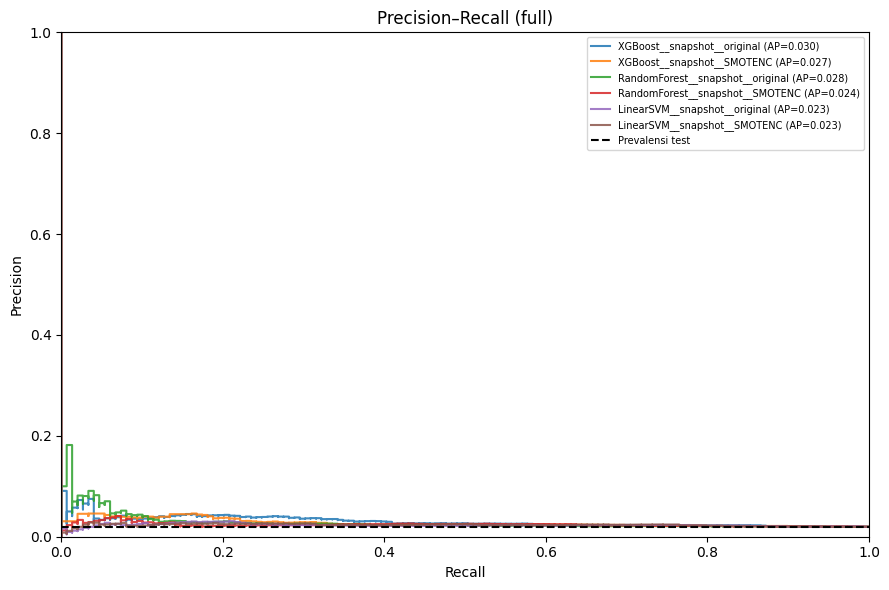

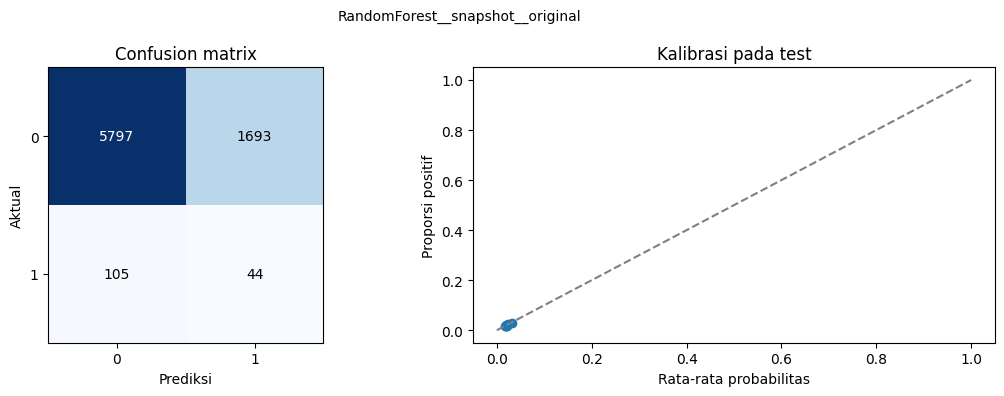

In [ ]:
fig,ax=plt.subplots(figsize=(9,6))
for row in decisions:
    if row['role']!='primary':continue
    name=row['name'];p,r,_=precision_recall_curve(Y_TEST,TEST_P[name])
    ap=average_precision_score(Y_TEST,TEST_P[name])
    ax.step(r,p,where='post',label=f'{name} (AP={ap:.3f})',alpha=.85)
ax.axhline(Y_TEST.mean(),ls='--',color='black',label='Prevalensi test')
ax.set(xlabel='Recall',ylabel='Precision',title=f'Precision–Recall ({RUN_MODE})',xlim=(0,1),ylim=(0,1))
ax.legend(fontsize=7);fig.tight_layout();fig.savefig(OUT/'figures'/'precision_recall.png',dpi=180);plt.show();plt.close(fig)
fig,axes=plt.subplots(1,2,figsize=(11,4))
cm=confusion_matrix(Y_TEST,TEST_PRED[selected_name],labels=[0,1]);axes[0].imshow(cm,cmap='Blues')
for i in range(2):
    for j in range(2):axes[0].text(j,i,str(cm[i,j]),ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black')
axes[0].set(xticks=[0,1],yticks=[0,1],xlabel='Prediksi',ylabel='Aktual',title='Confusion matrix')
frac,meanp=calibration_curve(Y_TEST,TEST_P[selected_name],n_bins=8,strategy='quantile')
axes[1].plot(meanp,frac,'o-');axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set(xlabel='Rata-rata probabilitas',ylabel='Proporsi positif',title='Kalibrasi pada test')
fig.suptitle(selected_name,fontsize=10);fig.tight_layout();fig.savefig(OUT/'figures'/'selected_model_diagnostics.png',dpi=180);plt.show();plt.close(fig)


In [ ]:
importance_rows=[]
if RUN_IMPORTANCE:
    chosen_for_importance=[]
    for alg in ['XGBoost','RandomForest','LinearSVM']:
        pick=primary[primary.algorithm.eq(alg)].sort_values(['best_cv_ap','name'],ascending=[False,True]).iloc[0]
        chosen_for_importance.append(pick['name'])
    blocks={'duration':['duration_seconds'],'title':['title_length'],
        'description':['description_length','has_description'],'tags':['tag_count','has_tags'],
        'publication_time':['video_age_days','publish_month','publish_dayofweek'],
        'channel_snapshot':channel_stats}
    Xp=df.iloc[test_idx][FEATURE_SETS['snapshot']].reset_index(drop=True).astype(float)
    for name in chosen_for_importance:
        baseline_ap=average_precision_score(Y_TEST,TEST_P[name])
        for block,cols in blocks.items():
            mode='between_channels' if block=='channel_snapshot' else 'within_channel'
            if mode=='between_channels':
                check=Xp[cols].assign(group=G_TEST).groupby('group').nunique(dropna=False)
                assert check.le(1).all().all(),'Statistik kanal tidak konstan; periksa rancangan permutation.'
            perm_rng=np.random.default_rng(SEED+20)
            for repeat in range(N_PERMUTATIONS):
                shuffled=Xp.copy()
                if mode=='within_channel':
                    for idx in group_rows:shuffled.loc[idx,cols]=Xp.loc[perm_rng.permutation(idx),cols].to_numpy()
                else:
                    donors=perm_rng.permutation(len(group_rows))
                    for receiver,donor in enumerate(donors):
                        value=Xp.loc[group_rows[donor][0],cols].to_numpy()
                        shuffled.loc[group_rows[receiver],cols]=np.tile(value,(len(group_rows[receiver]),1))
                p=models[name].predict_proba(shuffled)[:,1]
                importance_rows.append({'name':name,'block':block,'permutation':mode,'repeat':repeat,
                    'ap_drop':baseline_ap-average_precision_score(Y_TEST,p)})
    imp=pd.DataFrame(importance_rows);imp.to_csv(OUT/'block_permutation_repeats.csv',index=False)
    imp_summary=imp.groupby(['name','block','permutation']).ap_drop.agg(['mean','std','count']).reset_index()
    imp_summary.to_csv(OUT/'block_permutation_summary.csv',index=False);display(imp_summary)
else:print('Analisis kepentingan blok dinonaktifkan pada konfigurasi awal.')


,name,block,permutation,mean,std,count
0,LinearSVM__snapshot__original,channel_snapshot,between_channels,0.001518,0.001315,10
1,LinearSVM__snapshot__original,description,within_channel,-0.000154,0.000322,10
2,LinearSVM__snapshot__original,duration,within_channel,0.000016,0.000466,10
3,LinearSVM__snapshot__original,publication_time,within_channel,-0.000208,0.000599,10
4,LinearSVM__snapshot__original,tags,within_channel,-0.000792,0.001724,10
5,LinearSVM__snapshot__original,title,within_channel,0.000194,0.000296,10
6,RandomForest__snapshot__original,channel_snapshot,between_channels,0.005591,0.002664,10
7,RandomForest__snapshot__original,description,within_channel,0.002330,0.000626,10
8,RandomForest__snapshot__original,duration,within_channel,0.006227,0.001272,10
9,RandomForest__snapshot__original,publication_time,within_channel,0.002856,0.000810,10


## 11. Pemeriksaan akhir dan pelaporan
Keluaran utama: manifest split, konfigurasi, keputusan model, hasil test, interval bootstrap, selisih berpasangan, PFI blok, model, dan grafik. Angka penuh disimpan di CSV; pembulatan hanya untuk tampilan. Model tersimpan bersama urutan fitur dan ambang. Jangan muat joblib dari sumber tidak tepercaya.

Pada BAB III, laporkan **holdout calibration dan holdout threshold**, bukan OOF threshold seperti v10. Tidak ada nested-CV; evaluasi akhir memakai kanal test terpisah. Definisi niche, label relatif pada sampel maksimal 300 video, nol versus data tidak tersedia, snapshot, serta test lama yang pernah diamati tetap perlu dibahas.

Jika cohort video berubah, hitung ulang label dan keseluruhan eksperimen sebagai run baru. Jangan menulis hasil v10 seolah merupakan hasil notebook revisi.


In [ ]:
bundle=joblib.load(OUT/'models'/f'{selected_name}.joblib')
check_x=df.iloc[test_idx[:10]][bundle['features']]
np.testing.assert_allclose(bundle['model'].predict_proba(check_x)[:,1],TEST_P[selected_name][:10],rtol=1e-10,atol=1e-12)
assert hashlib.sha256((OUT/'model_decisions.json').read_bytes()).hexdigest()==LOCKED_DECISIONS_SHA
summary={'mode':RUN_MODE,'selected_before_test':selected_name,'data_sha256':DATA_SHA256,
    'clean_rows':len(df),'channels':df.channel_id.nunique(),'positives':int(df.is_viral.sum()),
    'experiments_completed':len(results),'bootstrap_valid':N_BOOTSTRAP-skipped,
    'all_partition_channel_overlaps':0,'model_reload_check':'passed',
    'note':'Smoke scores are not thesis results' if RUN_MODE=='smoke' else 'Reanalysis; old test previously inspected'}
save_json('run_summary.json',summary)
print('SELESAI:',OUT);print(json.dumps(summary,indent=2))


SELESAI: /content/drive/MyDrive/Metopen /hasil_v11/full_20260924T041949924077Z
{
  "mode": "full",
  "selected_before_test": "RandomForest__snapshot__original",
  "data_sha256": "a8ce478d27b368fc67629e2552325aabbdf62f9187c003bde139de1030e193c2",
  "clean_rows": 38929,
  "channels": 218,
  "positives": 712,
  "experiments_completed": 9,
  "bootstrap_valid": 1000,
  "all_partition_channel_overlaps": 0,
  "model_reload_check": "passed",
  "note": "Reanalysis; old test previously inspected"
}


## Referensi teknis
- [scikit-learn 1.6: CalibratedClassifierCV](https://scikit-learn.org/1.6/modules/generated/sklearn.calibration.CalibratedClassifierCV.html): FrozenEstimator untuk kalibrasi model terlatih pada data terpisah.
- [imbalanced-learn: SMOTENC](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTENC.html): resampling numerik dan kategorikal.
- [scikit-learn 1.6: Average Precision](https://scikit-learn.org/1.6/modules/generated/sklearn.metrics.average_precision_score.html): AP berbeda dari luas trapezoid kurva PR.

Dokumentasi ini mendukung implementasi, bukan pengganti sumber ilmiah definisi viralitas atau niche. Tidak ada hasil v10 yang disalin sebagai hasil v11.
